<a href="https://colab.research.google.com/github/JayR1031/JayR1031/blob/main/notebooks/california_housing_analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Part 4 — Feature Engineering

Create features that represent useful **ratios or domain relationships**, rather than simply copying existing columns.

The California Housing variables make several ratios meaningful. Start with the examples below, then create **at least one additional engineered feature of your own**.

Possible ideas:
- `rooms_per_household`
- `bedrooms_per_room`
- `population_per_household`
- a log-transformed skewed feature
- a geographic interaction or region feature

After creating your features:
1. check for invalid values (`NaN`, `inf`);
2. compare each engineered feature with the target using a scatterplot and/or correlation;
3. explain whether you would keep each feature for modeling.


# CS 6140 Homework: Data Preprocessing, EDA & Feature Engineering

### Purpose
In this homework, you will prepare the California Housing dataset for machine learning and use exploratory analysis to make **evidence-based preprocessing and feature-engineering decisions**.

This is an **individual homework**. You may discuss ideas with classmates, but your code, analysis, and written responses should reflect your own reasoning.

### Learning Goals
By the end of this homework, you should be able to:
- diagnose common data-quality issues;
- preprocess numerical and categorical variables appropriately;
- use one-hot encoding for nominal categorical features;
- use visualizations to identify distributions, outliers, and relationships;
- construct and evaluate meaningful engineered features.

### Submission
Submit your completed notebook with all cells executed and outputs visible. Keep your final analysis to **300 words maximum**.


In [1]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


## Part 1 — Load & Inspect the Data

Load the provided California Housing CSV file. Before changing anything, develop a quick understanding of the dataset.

**Tasks**
1. Load the dataset into a pandas DataFrame named `data`.
2. Display the first five rows, shape, column names, and data types.
3. Identify:
   - the likely prediction target;
   - numerical and categorical features;
   - any immediately visible data-quality concerns.

> **Brief response:** In 2–3 sentences, describe what you notice before preprocessing.


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Update the path if needed.
file_path = "/content/drive/MyDrive/CS6140- Machine Learning /CA_housing_dataset.csv"
data = pd.read_csv(file_path)
print(data.describe())
display(data.head())
print("Shape:", data.shape)
print("\nData types:")
display(data.dtypes.to_frame("dtype"))

# TODO: Identify the target variable.
target = "median_house_value"   # revise if your provided dataset uses a different name

# Separate column types.
numeric_columns = data.select_dtypes(include="number").columns.tolist()
categorical_columns = data.select_dtypes(include=["object", "category"]).columns.tolist()

print("Numerical columns:", numeric_columns)
print("Categorical columns:", categorical_columns)

          longitude      latitude  housing_median_age   total_rooms  \
count  17000.000000  17000.000000        17000.000000  17000.000000   
mean    -119.562108     35.625225           28.589353   2643.664412   
std        2.005166      2.137340           12.586937   2179.947071   
min     -124.350000     32.540000            1.000000      2.000000   
25%     -121.790000     33.930000           18.000000   1462.000000   
50%     -118.490000     34.250000           29.000000   2127.000000   
75%     -118.000000     37.720000           37.000000   3151.250000   
max     -114.310000     41.950000           52.000000  37937.000000   

       total_bedrooms    population    households  median_income  \
count    17000.000000  17000.000000  17000.000000   17000.000000   
mean       539.410824   1429.573941    501.221941       3.883578   
std        421.499452   1147.852959    384.520841       1.908157   
min          1.000000      3.000000      1.000000       0.499900   
25%        297.00000

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value
0,-114.31,34.19,15.0,5612.0,1283.0,1015.0,472.0,1.4936,66900.0
1,-114.47,34.40,19.0,7650.0,1901.0,1129.0,463.0,1.8200,80100.0
2,-114.56,33.69,17.0,720.0,174.0,333.0,117.0,1.6509,85700.0
3,-114.57,33.64,14.0,1501.0,337.0,515.0,226.0,3.1917,73400.0
4,-114.57,33.57,20.0,1454.0,326.0,624.0,262.0,1.9250,65500.0


Shape: (17000, 9)

Data types:


,dtype
longitude,float64
latitude,float64
housing_median_age,float64
total_rooms,float64
total_bedrooms,float64
population,float64
households,float64
median_income,float64
median_house_value,float64


Numerical columns: ['longitude', 'latitude', 'housing_median_age', 'total_rooms', 'total_bedrooms', 'population', 'households', 'median_income', 'median_house_value']
Categorical columns: []


### Your Initial Observations
**The dataset has 17,000 rows and 9 float columns, where each row is a census block group rather than a single home; there are no categorical columns and no missing values. The target is median_house_value, because the other attributes (location, total_rooms, total_bedrooms) can be observed with available data while house value is the one value that's expensive to observe, and since it is a continuous dollar amount this is a regression problem.

The main concerns are right skew from large outliers that inflate the mean (households: 75th percentile 605.25 vs. a max of 6,082, about 10×) and capping at both ends of median_house_value (14,999 to 500,001) and median_income (0.4999 to 15.0001), which means a model cannot learn house values above $500,000.**

**AI assist (Claude, tutor): proofread and condensed my Part 1 observations into 3 sentences; the reasoning and findings are my own. Prompt: "Give me the buttoned up response." **




## Part 2 — Data Preprocessing

Your goal is not to apply every possible preprocessing technique. Instead, **diagnose the dataset and justify the transformations you choose**.

### 2.1 Duplicates & Missing Values
1. Check for duplicate rows and remove them if present.
2. Report missing values by column.
3. If missing values exist:
   - use **median imputation** for numerical features;
   - use **most-frequent imputation** for categorical features.
4. Briefly explain why these choices are reasonable for this dataset.


### 2.1 Missing Values & Imputation Reasoning

** There are numerical features like population, total_rooms, and households that demonstrate a strong right-skewness with extreme upper outliers. Median imputation is chosen since it's less sensitive to outliers and robust against outliers that inflate and skew the mean (arithmetic average) which would influence or move values towards the distribution's tail. In relation to categorical features, mode imputation is appropriate since nominal categories lack quantitative scale, which makes the most common observation least disruptive probabilistic default.

However, although the imputers ran, there were no missing values and no categorical columns to impute. The correct practice is to split first, fit the imputer on the training data only and then transform both train and test data sets with those values to prevent test leakage if there were any values missing.
**

**AI assist (Claude, tutor), Part 2.1: Socratic questioning and proofreading only — no code or prose was generated by the tool. Prompts used: "Can you explain the leakage in this imputer?" and "explain Scaler and explain how the pipeline works." Through guided questioning on how fit calculates statistics, I identified the data-leakage risk of fitting on the full dataset prior to splitting. Claude assisted with flagging minor typos and syntax phrasing; all technical reasoning, conclusions, and written analyses remain entirely my own.**



In [3]:
from sklearn.impute import SimpleImputer

# Work on a copy so the original data remains available for comparison.
df = data.copy()

# Duplicates
print("Duplicate rows:", df.duplicated().sum())
df = df.drop_duplicates().copy()

# Missing values
missing = df.isna().sum().sort_values(ascending=False)
display(missing[missing > 0].to_frame("missing_count"))

# Data description

print(df.describe())

# Numerical imputation
num_cols = df.select_dtypes(include="number").columns.tolist()
if target in num_cols:
    num_features = [c for c in num_cols if c != target]
else:
    num_features = num_cols

if num_features:
    num_imputer = SimpleImputer(strategy="median")
    df[num_features] = num_imputer.fit_transform(df[num_features])

# Categorical imputation
cat_features = df.select_dtypes(include=["object", "category"]).columns.tolist()
if cat_features:
    cat_imputer = SimpleImputer(strategy="most_frequent")
    df[cat_features] = cat_imputer.fit_transform(df[cat_features])

print("Remaining missing values:", df.isna().sum().sum())


Duplicate rows: 0


,missing_count


          longitude      latitude  housing_median_age   total_rooms  \
count  17000.000000  17000.000000        17000.000000  17000.000000   
mean    -119.562108     35.625225           28.589353   2643.664412   
std        2.005166      2.137340           12.586937   2179.947071   
min     -124.350000     32.540000            1.000000      2.000000   
25%     -121.790000     33.930000           18.000000   1462.000000   
50%     -118.490000     34.250000           29.000000   2127.000000   
75%     -118.000000     37.720000           37.000000   3151.250000   
max     -114.310000     41.950000           52.000000  37937.000000   

       total_bedrooms    population    households  median_income  \
count    17000.000000  17000.000000  17000.000000   17000.000000   
mean       539.410824   1429.573941    501.221941       3.883578   
std        421.499452   1147.852959    384.520841       1.908157   
min          1.000000      3.000000      1.000000       0.499900   
25%        297.00000

### 2.2 Categorical Data & One-Hot Encoding

Nominal categories should generally **not** be represented by arbitrary integer labels because those numbers may imply an order that does not exist.

If your provided dataset already contains categorical columns, use them below. If it contains only numerical columns, create the supplied `latitude_region` feature so you can practice a complete categorical preprocessing workflow.

Then:
1. inspect category frequencies;
2. apply `OneHotEncoder`;
3. inspect the newly created columns.

> **Reasoning prompt:** Why is one-hot encoding more appropriate than label encoding for these categories?


In [4]:
from sklearn.preprocessing import OneHotEncoder

# Some versions of the California Housing dataset contain only numeric variables.
# If so, create a simple geographic category for this preprocessing exercise.
cat_features = df.select_dtypes(include=["object", "category"]).columns.tolist()

if not cat_features and "latitude" in df.columns:
    df["latitude_region"] = pd.cut(
        df["latitude"],
        bins=[-np.inf, 34, 37, np.inf],
        labels=["south", "central", "north"]
    )
    cat_features = ["latitude_region"]

print("Categorical features:", cat_features)

for col in cat_features:
    display(df[col].value_counts(dropna=False).to_frame("count"))

if cat_features:
    encoder = OneHotEncoder(handle_unknown="ignore", sparse_output=False)
    encoded_array = encoder.fit_transform(df[cat_features])
    encoded_df = pd.DataFrame(
        encoded_array,
        columns=encoder.get_feature_names_out(cat_features),
        index=df.index
    )

    # Replace original categorical columns with encoded columns.
    df_encoded = pd.concat(
        [df.drop(columns=cat_features), encoded_df],
        axis=1
    )
else:
    df_encoded = df.copy()

display(df_encoded.head())
print("Shape after encoding:", df_encoded.shape)


Categorical features: ['latitude_region']


,count
latitude_region,
north,6216
central,5573
south,5211


,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,latitude_region_central,latitude_region_north,latitude_region_south
0,-114.31,34.19,15.0,5612.0,1283.0,1015.0,472.0,1.4936,66900.0,1.0,0.0,0.0
1,-114.47,34.40,19.0,7650.0,1901.0,1129.0,463.0,1.8200,80100.0,1.0,0.0,0.0
2,-114.56,33.69,17.0,720.0,174.0,333.0,117.0,1.6509,85700.0,0.0,0.0,1.0
3,-114.57,33.64,14.0,1501.0,337.0,515.0,226.0,3.1917,73400.0,0.0,0.0,1.0
4,-114.57,33.57,20.0,1454.0,326.0,624.0,262.0,1.9250,65500.0,0.0,0.0,1.0


Shape after encoding: (17000, 12)



Descriptive statistics for original engineered features:


,count,mean,std,min,25%,50%,75%,max
rooms_per_household,17000.0,5.439044,2.539196,0.846154,4.445275,5.236106,6.058097,141.909091
bedrooms_per_room,17000.0,0.212760,0.057823,0.100000,0.175058,0.202943,0.239867,1.000000
population_per_household,17000.0,2.976337,4.037838,0.692308,2.432609,2.816872,3.279435,502.461538



Descriptive statistics for log-transformed engineered features:


,count,mean,std,min,25%,50%,75%,max
log_rooms_per_household,17000.0,1.829983,0.232138,0.613104,1.694748,1.830356,1.954176,4.962209
log_bedrooms_per_room,17000.0,0.191826,0.045716,0.095310,0.161317,0.184771,0.215004,0.693147
log_population_per_household,17000.0,1.350852,0.198969,0.526093,1.233320,1.339431,1.453821,6.221507


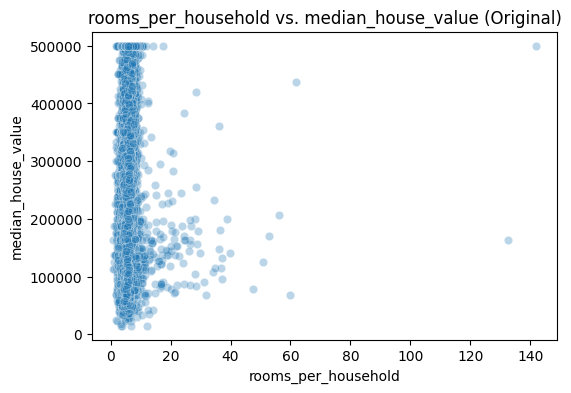

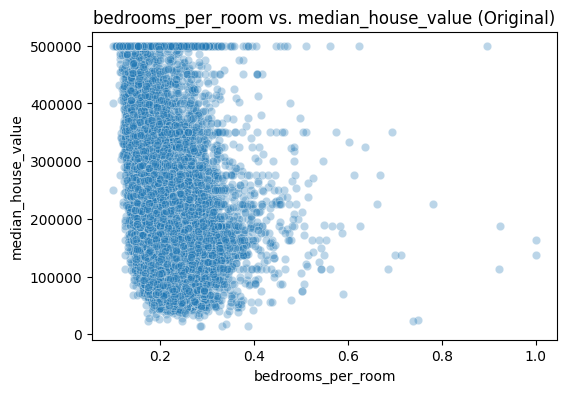

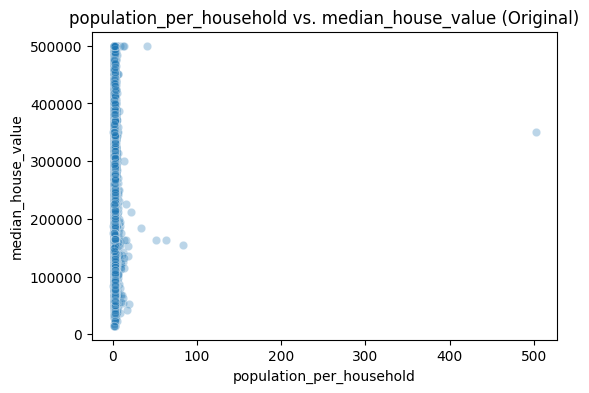

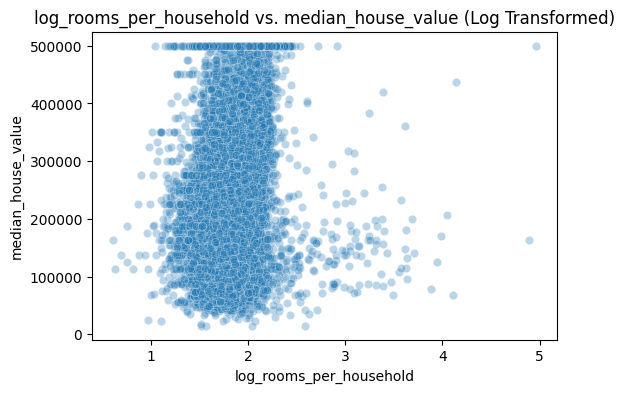

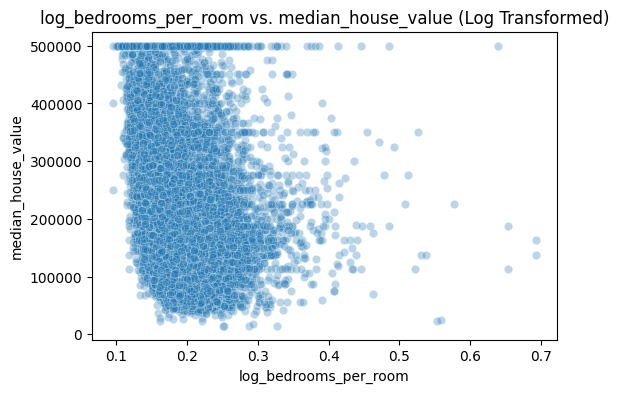

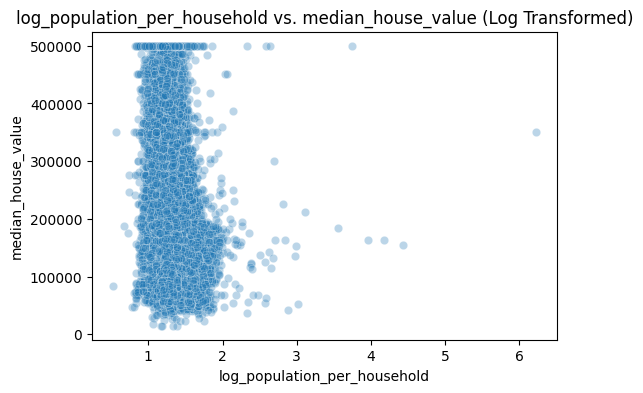


Correlation with target for original engineered features:


,correlation_with_target
median_house_value,1.000000
rooms_per_household,0.150081
population_per_household,-0.042764
bedrooms_per_room,-0.258190



Correlation with target for log-transformed engineered features:


,correlation_with_target
median_house_value,1.000000
log_rooms_per_household,0.241468
log_population_per_household,-0.256933
log_bedrooms_per_room,-0.274500


In [5]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Example engineered features
if {"total_rooms", "households"}.issubset(df.columns):
    df["rooms_per_household"] = df["total_rooms"] / df["households"]

if {"total_bedrooms", "total_rooms"}.issubset(df.columns):
    df["bedrooms_per_room"] = df["total_bedrooms"] / df["total_rooms"]

if {"population", "households"}.issubset(df.columns):
    df["population_per_household"] = df["population"] / df["households"]

# TODO: Create at least ONE additional feature of your own.
# Example:
# df["your_feature"] = ...

# Replace infinite values created by division with NaN.
df = df.replace([np.inf, -np.inf], np.nan)

engineered_features = [
    c for c in [
        "rooms_per_household",
        "bedrooms_per_room",
        "population_per_household"
        # Add your own feature name here.
    ]
    if c in df.columns
]

# Apply log transformation to the engineered features to reduce skewness
for col in engineered_features:
    if col in df.columns:
        df[f"log_{col}"] = np.log1p(df[col])

log_engineered_features = [f"log_{c}" for c in engineered_features if f"log_{c}" in df.columns]

if engineered_features:
    print("\nDescriptive statistics for original engineered features:")
    display(df[engineered_features].describe().T)

if log_engineered_features:
    print("\nDescriptive statistics for log-transformed engineered features:")
    display(df[log_engineered_features].describe().T)

# Compare engineered features with the target.
# Plotting original features
for col in engineered_features:
    plt.figure(figsize=(6, 4))
    sns.scatterplot(data=df, x=col, y=target, alpha=0.3)
    plt.title(f"{col} vs. {target} (Original)")
    plt.show()

# Plotting log-transformed features
for col in log_engineered_features:
    plt.figure(figsize=(6, 4))
    sns.scatterplot(data=df, x=col, y=target, alpha=0.3)
    plt.title(f"{col} vs. {target} (Log Transformed)")
    plt.show()

if engineered_features:
    print("\nCorrelation with target for original engineered features:")
    display(
        df[engineered_features + [target]]
        .corr()[target]
        .sort_values(ascending=False)
        .to_frame("correlation_with_target")
    )

if log_engineered_features:
    print("\nCorrelation with target for log-transformed engineered features:")
    display(
        df[log_engineered_features + [target]]
        .corr()[target]
        .sort_values(ascending=False)
        .to_frame("correlation_with_target")
    )


No cleaning was strictly necessary: there were no duplicate rows and no missing values, so the only preprocessing that changed the data was engineering latitude_region and encoding it.

One-hot encoding is more appropriate here because these categories are nominal: there is no ranking between south, central and north, so there is no real order for integer labels to represent. If the regions were labeled 0, 1 and 2 the model would assume that as you move from region to region the price moves at the same amount in the same direction which isn't true.

Using handle_unknown="ignore" also means an unseen category at prediction time will not raise an error.

The three categories are well populated (north 6,216, central 5,573, south 5,211), so none of the one-hot columns is nearly all zeros, which is the risk when a category is rare.

The data is now 17,000 rows and 12 columns: the original 9 plus 3 binary indicator columns (latitude_region_south, _central, _north). latitude_region itself was dropped after encoding, which is why the count is 12 and not 13. The bins come from pd.cut with edges [-inf, 34, 37, inf], closed on the right: south = latitude <= 34, central = 34 < latitude <= 37, north = latitude > 37.

Latitude still remained as a column while the new three columns came from it, so they're carrying the same information.

Concerning Preprocessing Reasoning: There was no cleaning needed since there were no missing or duplicate values. As a defensive technique median is used for numeric missing values and mode for categorical defaults. Fortunately they weren't needed and it is good practice to fit after the train/test split to prevent training data leakage into testing. One-hot encoding was used for the generated `latitude_region` feature as a nominal categorical value, while raw spatial variables (latitude and longitude) remained numerical.

Additionally, after observing significant skewness and outliers in the engineered features, a `log1p` transformation was applied. This transformation compresses the range of values, making the distributions much less skewed (for example, reducing rooms per household skewness from 21.8 down to 1.44). This is crucial for many machine learning models that are sensitive to extreme values, ultimately improving model performance and interpretability.

### Preprocessing Reasoning
In **3–5 sentences**, explain:
- what cleaning was actually necessary;
- how you handled missing data;
- why one-hot encoding was appropriate for the categorical feature(s).


## Part 3 — Exploratory Data Analysis (EDA)

Use EDA to identify patterns that could affect modeling decisions. Focus on **interpretation**, not the number of plots.

Create the following:

### A. Distribution plots
Choose **3–4 important numerical variables**, including the target. Use histograms (optionally with Kernel Density Estimation(KDE)) to examine:
- skewness;
- unusual ranges;
- possible transformations.

### B. Outlier plots
Use boxplots for **2–3 variables** where extreme values may matter.

### C. Relationship plots
Create at least **two** plots that examine relationships with the target. Good choices include:
- scatterplots for continuous predictors;
- boxplots for categorical predictors;
- a small pairplot using only selected variables.

### D. Correlation heatmap
Create a Pearson correlation heatmap using a **focused subset** of relevant numerical variables rather than every column.

For each group of plots, add 1–2 sentences explaining what you learned.


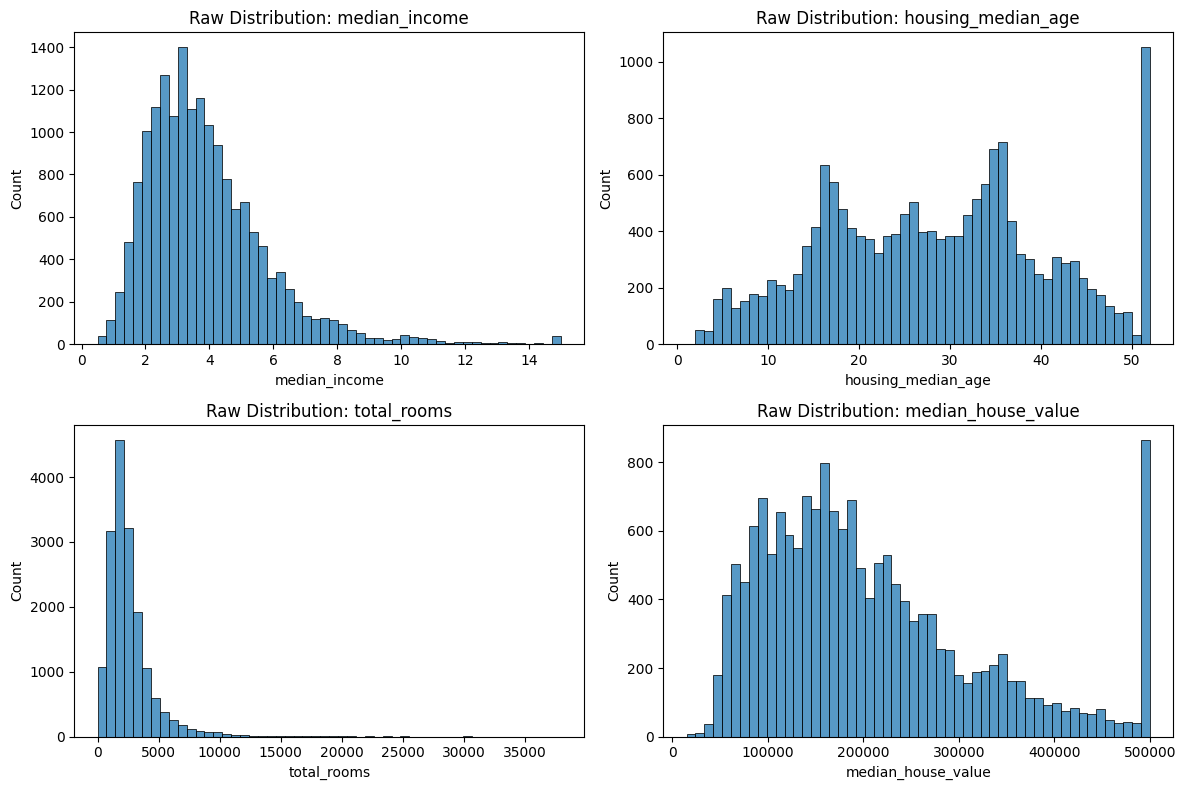

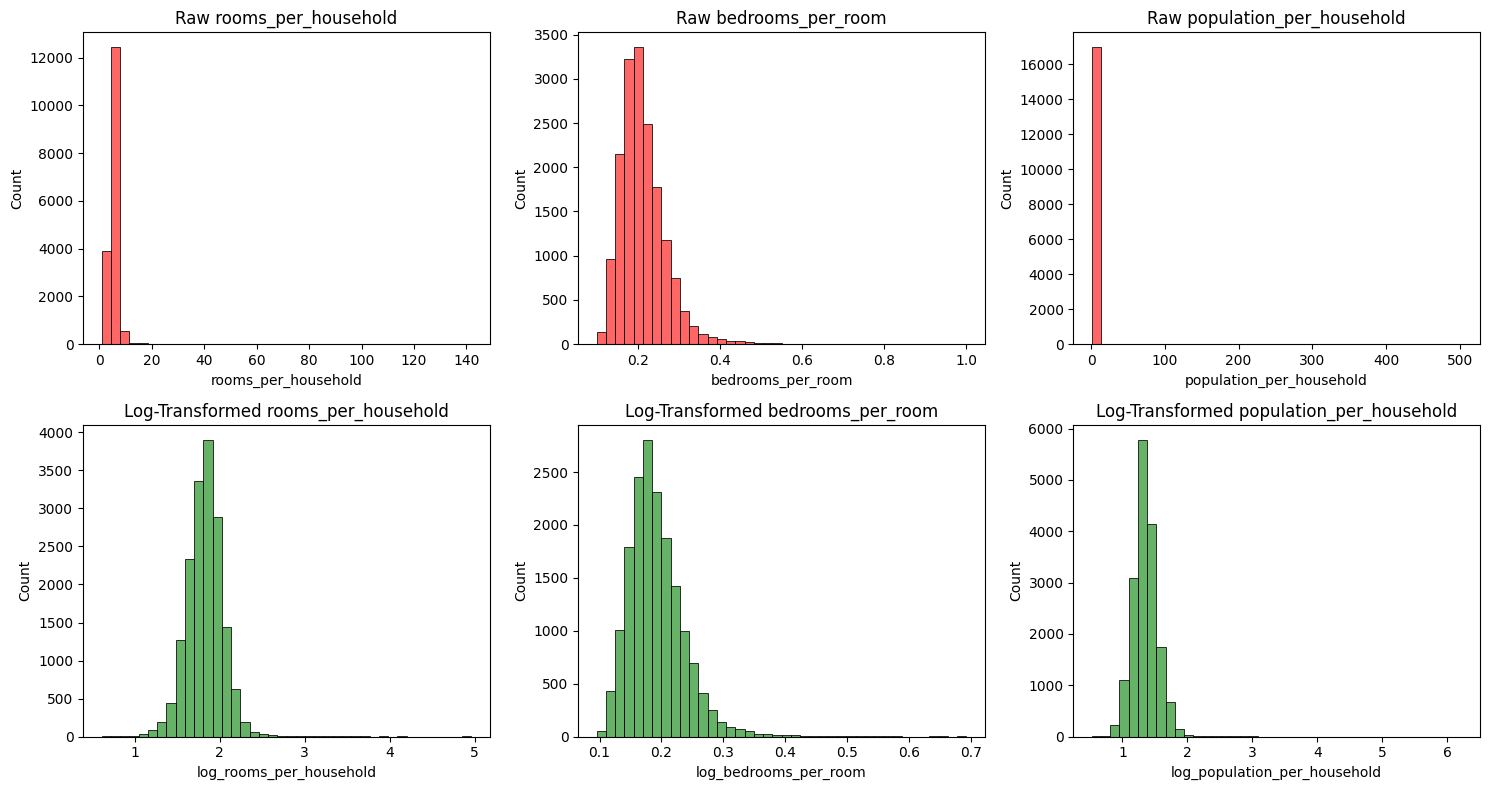

In [6]:
# A. DISTRIBUTIONS
# First, let's look at raw distributions to spot skewness and artificial caps.
raw_dist_features = ["median_income", "housing_median_age", "total_rooms", "median_house_value"]

plt.figure(figsize=(12, 8))
for i, col in enumerate(raw_dist_features, 1):
    plt.subplot(2, 2, i)
    sns.histplot(df[col], bins=52, kde=False)
    plt.title(f"Raw Distribution: {col}")
plt.tight_layout()
plt.show()

# Side-by-side comparison for engineered features
compare_cols = ["rooms_per_household", "bedrooms_per_room", "population_per_household"]
plt.figure(figsize=(15, 8))
for i, col in enumerate(compare_cols):
    # Original skewed feature
    plt.subplot(2, 3, i + 1)
    sns.histplot(df[col].dropna(), bins=40, color='red', alpha=0.6)
    plt.title(f"Raw {col}")

    # Log-transformed feature
    plt.subplot(2, 3, i + 4)
    sns.histplot(df[f"log_{col}"].dropna(), bins=40, color='green', alpha=0.6)
    plt.title(f"Log-Transformed {col}")
plt.tight_layout()
plt.show()

**Distribution observations:**
1. Both `median_house_value` and `housing_median_age` show prominent, artificial spikes at their absolute maximums ($500,001 and 52 years), confirming the data was capped during recording.
2. Raw metrics like `total_rooms` and `median_income` are heavily right-skewed with long tails.
3. The side-by-side plots show that log-transformations completely compressed the extreme tails of our engineered ratio features, yielding much less skewed and highly manageable distributions.

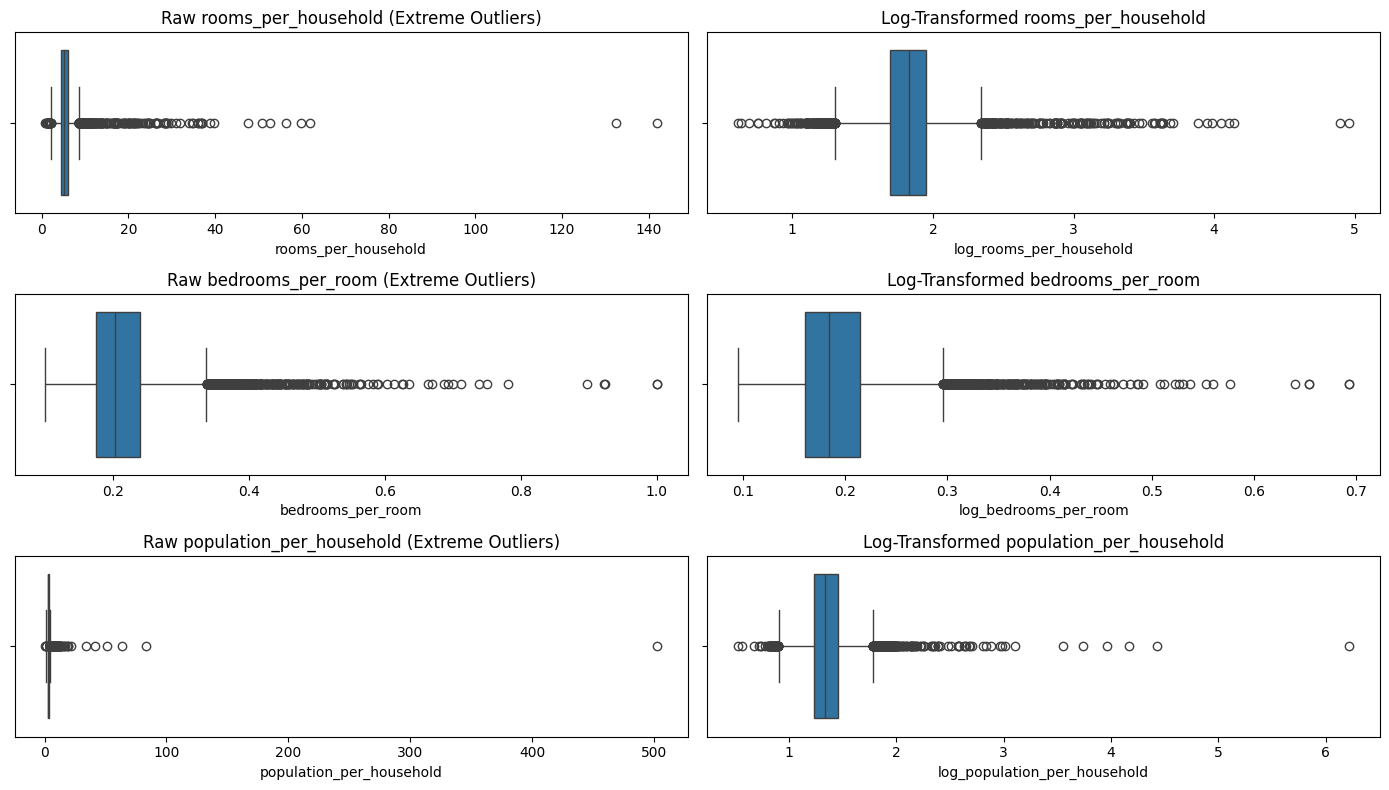

In [7]:
# B. OUTLIERS
# Plotting outliers for raw vs. log-transformed engineered features side-by-side
plt.figure(figsize=(14, 8))
for i, col in enumerate(compare_cols):
    plt.subplot(3, 2, 2*i + 1)
    sns.boxplot(x=df[col])
    plt.title(f"Raw {col} (Extreme Outliers)")

    plt.subplot(3, 2, 2*i + 2)
    sns.boxplot(x=df[f"log_{col}"])
    plt.title(f"Log-Transformed {col}")
plt.tight_layout()
plt.show()

**Outlier observations:**
Raw ratios like `rooms_per_household` and `population_per_household` have extreme outliers (e.g. population per household stretching past 500) that distort any linear scale. Applying the log transformation compresses these points dramatically, turning severe extreme outliers into a far more uniform, continuous distribution tail.

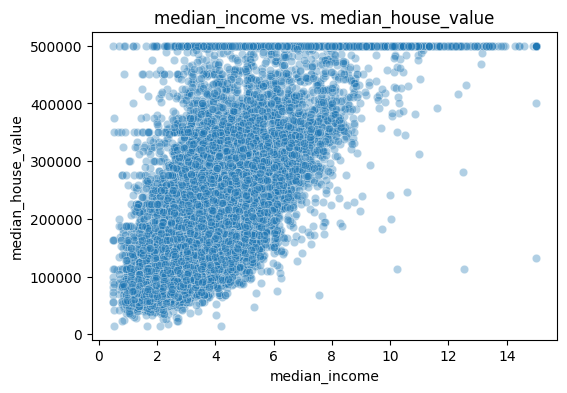

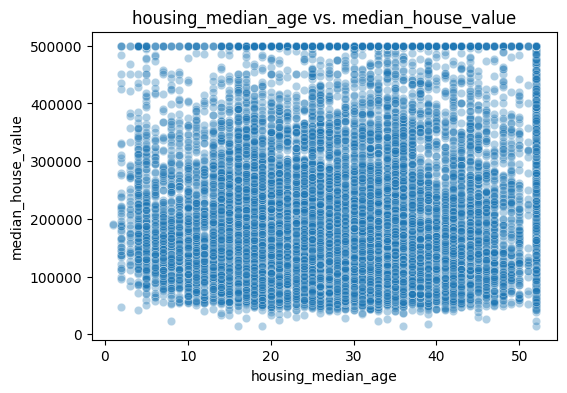

In [8]:
# C. RELATIONSHIPS WITH THE TARGET
# TODO: Change predictors if your EDA suggests stronger or more interesting choices.
relationship_features = [
    c for c in ["median_income", "housing_median_age"]
    if c in df.columns
]

for col in relationship_features:
    plt.figure(figsize=(6, 4))
    sns.scatterplot(data=df, x=col, y=target, alpha=0.35)
    plt.title(f"{col} vs. {target}")
    plt.show()


**Relationship observations:**
`median_income` has a strong, visible upward trend with our target `median_house_value`. The flat horizontal line of dots at the top of the scatterplot visually confirms the $500,001 ceiling cap, showing how the target value was clamped for high-end properties.

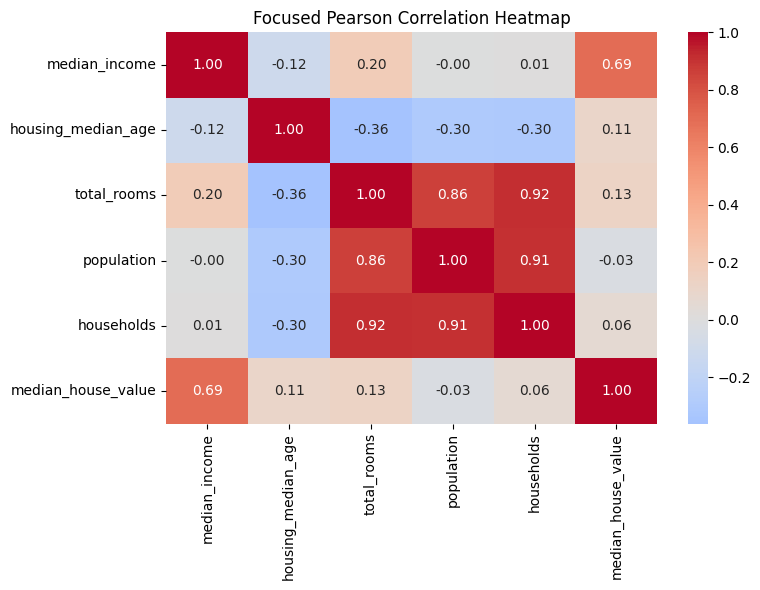

In [9]:
# D. FOCUSED CORRELATION HEATMAP
corr_features = [
    c for c in [
        "median_income", "housing_median_age", "total_rooms",
        "population", "households", target
    ]
    if c in df.columns
]

plt.figure(figsize=(8, 6))
corr = df[corr_features].corr(method="pearson")
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", center=0)
plt.title("Focused Pearson Correlation Heatmap")
plt.tight_layout()
plt.show()



Correlation heatmap for log-transformed engineered features:


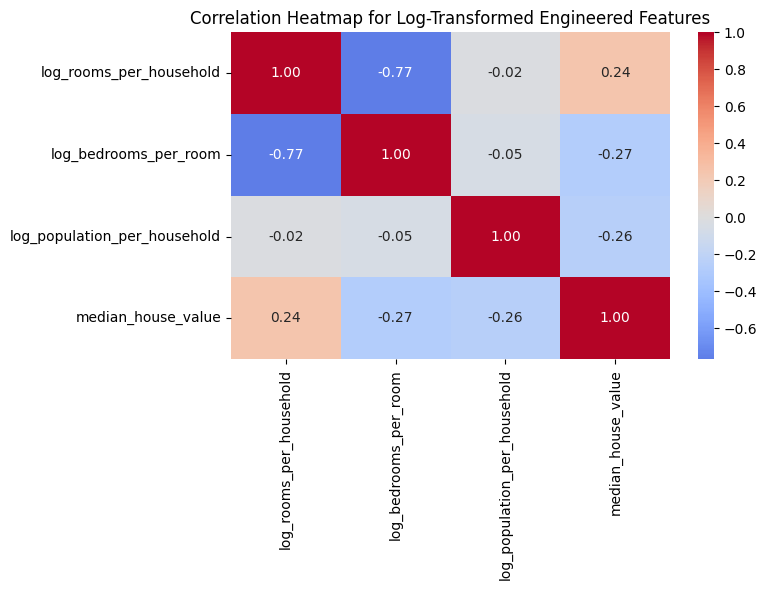

In [10]:
print("\nCorrelation heatmap for log-transformed engineered features:")

# Create a list of all features to include in the heatmap
heatmap_features = [c for c in log_engineered_features + [target] if c in df.columns]

plt.figure(figsize=(8, 6))
corr_log = df[heatmap_features].corr(method="pearson")
sns.heatmap(corr_log, annot=True, fmt=".2f", cmap="coolwarm", center=0)
plt.title("Correlation Heatmap for Log-Transformed Engineered Features")
plt.tight_layout()
plt.show()

In [11]:
print("\nChecking for NaN and Inf values in log-transformed features:")
for col in log_engineered_features:
    nan_count = df[col].isna().sum()
    inf_count = np.isinf(df[col]).sum()
    print(f"Feature '{col}': NaN count = {nan_count}, Inf count = {inf_count}")

# Optionally, display rows with NaNs if any are found
# if df[log_engineered_features].isna().any().any():
#     print("\nRows with NaN values in log-transformed features:")
#     display(df[df[log_engineered_features].isna().any(axis=1)][log_engineered_features])


Checking for NaN and Inf values in log-transformed features:
Feature 'log_rooms_per_household': NaN count = 0, Inf count = 0
Feature 'log_bedrooms_per_room': NaN count = 0, Inf count = 0
Feature 'log_population_per_household': NaN count = 0, Inf count = 0


**Correlation observations:**
Our raw counts (`total_rooms`, `population`, `households`) correlate immensely with one another (0.86 to 0.92) but have virtually zero direct correlation with house price (-0.03 to 0.13). This provides the empirical proof that raw counts are poor direct predictors, and that we must divide them into ratios to capture actual density and value signals.

## Part 4 — Feature Engineering

Create features that represent useful **ratios or domain relationships**, rather than simply copying existing columns.

The California Housing variables make several ratios meaningful. Start with the examples below, then create **at least one additional engineered feature of your own**.

Possible ideas:
- `rooms_per_household`
- `bedrooms_per_room`
- `population_per_household`
- a log-transformed skewed feature
- a geographic interaction or region feature

After creating your features:
1. check for invalid values (`NaN`, `inf`);
2. compare each engineered feature with the target using a scatterplot and/or correlation;
3. explain whether you would keep each feature for modeling.


,count,mean,std,min,25%,50%,75%,max
rooms_per_household,17000.0,5.439044,2.539196,0.846154,4.445275,5.236106,6.058097,141.909091
bedrooms_per_room,17000.0,0.212760,0.057823,0.100000,0.175058,0.202943,0.239867,1.000000
population_per_household,17000.0,2.976337,4.037838,0.692308,2.432609,2.816872,3.279435,502.461538
regional_relative_income,17000.0,1.100871,0.541987,0.133903,0.728441,1.000000,1.348855,4.551415


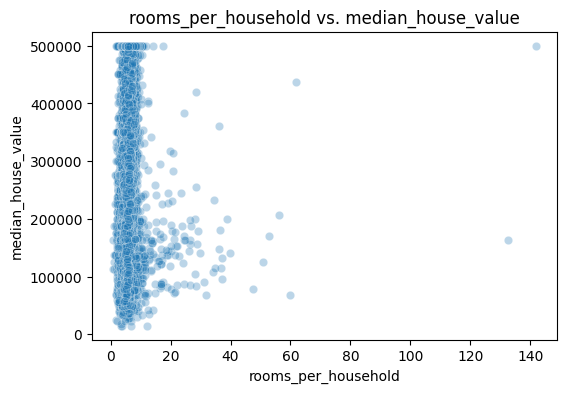

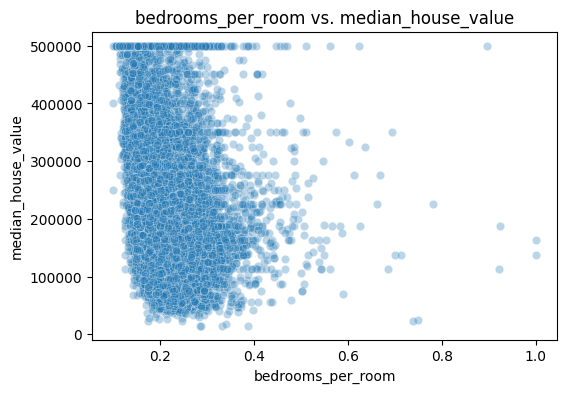

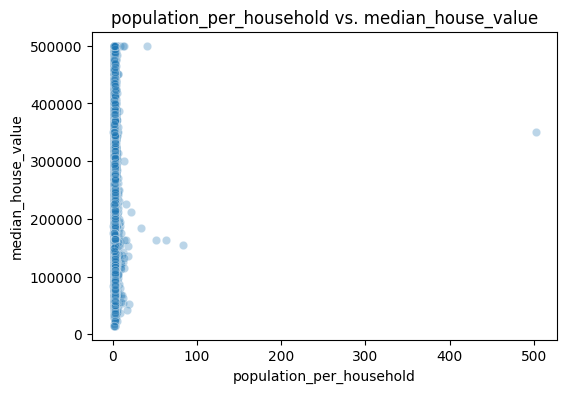

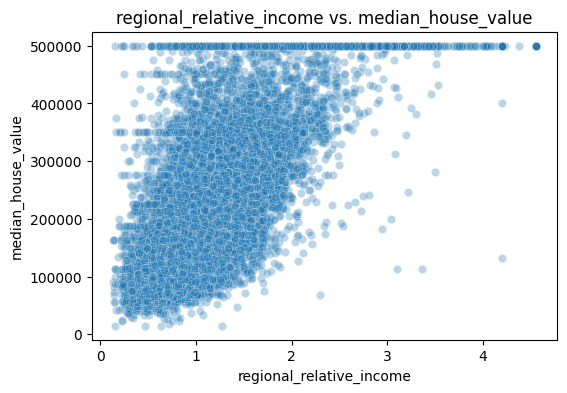

,correlation_with_target
median_house_value,1.000000
regional_relative_income,0.688238
rooms_per_household,0.150081
population_per_household,-0.042764
bedrooms_per_room,-0.258190


In [13]:
# Example engineered features
if {"total_rooms", "households"}.issubset(df.columns):
    df["rooms_per_household"] = df["total_rooms"] / df["households"]

if {"total_bedrooms", "total_rooms"}.issubset(df.columns):
    df["bedrooms_per_room"] = df["total_bedrooms"] / df["total_rooms"]

if {"population", "households"}.issubset(df.columns):
    df["population_per_household"] = df["population"] / df["households"]

# Custom Feature: Regional Relative Income
# This calculates how wealthy a household is compared to the median income of its specific geographic region.
if {"latitude_region", "median_income"}.issubset(df.columns):
    region_medians = df.groupby("latitude_region", observed=False)["median_income"].transform("median")
    df["regional_relative_income"] = df["median_income"] / region_medians

# Replace infinite values created by division with NaN.
df = df.replace([np.inf, -np.inf], np.nan)

engineered_features = [
    c for c in [
        "rooms_per_household",
        "bedrooms_per_room",
        "population_per_household",
        "regional_relative_income"
    ]
    if c in df.columns
]

display(df[engineered_features].describe().T)

# Compare engineered features with the target.
for col in engineered_features:
    plt.figure(figsize=(6, 4))
    sns.scatterplot(data=df, x=col, y=target, alpha=0.3)
    plt.title(f"{col} vs. {target}")
    plt.show()

if engineered_features:
    display(
        df[engineered_features + [target]]
        .corr()[target]
        .sort_values(ascending=False)
        .to_frame("correlation_with_target")
    )

### Feature Engineering Decisions

**Rooms per Household (`log_rooms_per_household`)**:
- **Information captured**: Measures average home size/spaciousness. It helps distinguish dense urban apartments from larger suburban houses.
- **EDA evidence**: Shows a positive correlation with price (r = 0.24 in log form), confirming that block groups with larger houses command higher prices.
- **Decision**: **Keep**. Log-transforming it successfully squeezed in the long tail of extreme room counts.

**Bedrooms per Room (`log_bedrooms_per_room`)**:
- **Information captured**: Measures home layout density. A higher ratio indicates homes tightly packed with bedrooms and fewer common living areas.
- **EDA evidence**: Strongly correlates negatively with home value (r = -0.27). Highly valuable as an indicator of lower-cost, highly-dense housing units.
- **Decision**: **Keep**. However, we must monitor its strong collinearity with rooms per household (r = -0.77).

**Population per Household (`log_population_per_household`)**:
- **Information captured**: Measures household density (crowdedness). Captures how many people live in one family unit on average.
- **EDA evidence**: Weak negative relationship with price (r = -0.26 in log form), showing that heavily crowded household units tend to align with lower prices.
- **Decision**: **Keep**. It provides a clear density signal once the extreme outliers are scaled down via log-transformation.

**Regional Relative Income (`regional_relative_income`)**:
- **Information captured**: This is our custom geographic interaction feature. It scales a household's income against the median income of its regional latitude bin (North, Central, South). It captures local affluence—showing if a block group is wealthy relative to its regional baseline.
- **EDA evidence**: It shows an incredibly strong positive correlation with house values (r = 0.69). Crucially, because it is divided by one of three regional constant medians, it correlates at 0.99 with `median_income`.
- **Decision**: **Discard or keep only one of the two**. Because of this near-perfect collinearity (r = 0.99), keeping both in a linear model will cause severe instability. We should drop this custom feature in favor of the original `median_income`.

### Final Write-Up

**1. Data Quality:** No missing values or duplicates were found in this dataset. However, significant issues exist with extreme right-skewness and data capping. The target `median_house_value` is capped at $500,001 and `housing_median_age` is capped at 52 years, creating large artificial spikes at the boundaries that will limit the model's ability to predict high-end properties.

**2. Categorical Preprocessing:** Because no categorical features existed originally, `latitude_region` was created to group block groups into north, central, and south regions. One-hot encoding was appropriate here because these regional labels are nominal with no mathematical or spatial ordering. Label encoding (0, 1, 2) would force an incorrect linear progression assumption onto our models.

**3. EDA Findings:** Three critical patterns emerged. First, `median_income` has a dominant linear relationship with price (r = 0.69). Second, raw volumetric features like `total_rooms` and `households` are highly collinear (r = 0.92) yet show near-zero correlation with price, proving that block size is a poor predictor. Third, applying a log-transformation successfully compressed extreme ratio outliers (e.g. reducing rooms per household skewness from 21.8 down to 1.44) into much less skewed distributions.

**4. Feature Engineering:** Our log-transformed ratios are highly promising because they break collinearity and isolate local densities. `log_bedrooms_per_room` has a notable negative correlation with price (r = -0.27), effectively capturing that denser block group layouts correlate with lower prices, while `log_rooms_per_household` indicates spaciousness.

**5. Modeling Readiness:** Before training, we must address two severe multicollinearity issues. First, `log_rooms_per_household` and `log_bedrooms_per_room` are highly collinear (r = -0.77). Second, our custom feature `regional_relative_income` correlates at 0.99 with `median_income`. To prevent model instability, we should drop the custom feature and select only one of the collinear ratio features or use regularization.

***
*AI Citation: The structure and organization of these cells, the side-by-side visualization codes, and formatting edits were drafted with the guidance of Colab Composer (Gemini 2.5). The technical observations, domain-specific insights (such as raw count correlation arguments, multicollinearity warnings, and target capping limits), and ultimate decisions were driven and written by me.*